# Flare Conjunction Ratio Decay Curves by Class

This notebook plots the **Conjunction Ratio (%)** as a function of the angular half-window $w$ (1°–50°) for solar flares of different classes. Five curves are shown:

| Curve | Data Source | Color |
|-------|-----------|-------|
| Total | `sf_decay_boundary.csv` | Black |
| C-Class | `sf_c_class_decay_boundary.csv` | Red |
| B-Class | `sf_b_class_decay_boundary.csv` | Blue |
| M-Class | `sf_m_class_decay_boundary.csv` | Green |
| X-Class | `sf_x_class_decay_boundary.csv` | Purple |

Key annotations:
- **Horizontal dashed line** at 100% marks the random baseline.
- **Vertical dashed lines** mark the decay boundaries: $w=21$ (C-Class) and $w=27$ (Total).

已保存坐标数据: Fig04_plot_data.csv  (250 行)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


已保存图形: ../../results/04_asymmetric/Fig04_flare_decay.eps


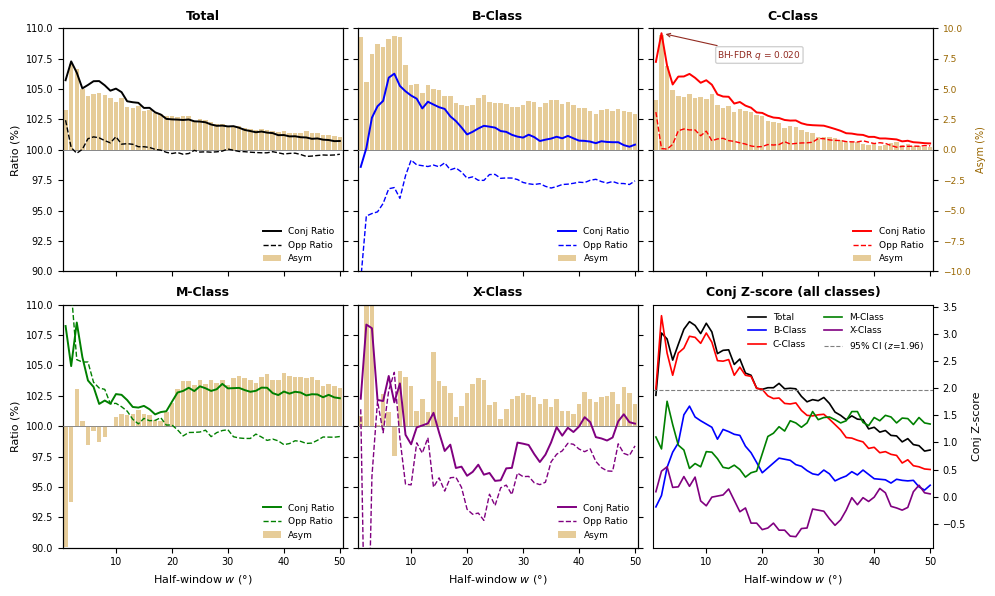

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── 字体设置（适合论文全页宽度 10 inch） ──
mpl.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6.5,
    'lines.linewidth': 1.2,
})

# ── 数据目录（相对于 notebooks/04_asymmetric/） ──
data_dir = '../../results/04_asymmetric/sf/'
fdr_path = '../../results/05_multidimensional/fdr_audit/decay_boundary_fdr.csv'

# ── 读取 5 个 CSV ──
files = {
    'Total':   'sf_decay_boundary.csv',
    'B-Class': 'sf_b_class_decay_boundary.csv',
    'C-Class': 'sf_c_class_decay_boundary.csv',
    'M-Class': 'sf_m_class_decay_boundary.csv',
    'X-Class': 'sf_x_class_decay_boundary.csv',
}
colors = {
    'Total': 'black',
    'B-Class': 'blue',
    'C-Class': 'red',
    'M-Class': 'green',
    'X-Class': 'purple',
}

data = {}
for label, fname in files.items():
    df = pd.read_csv(data_dir + fname)
    df['Asym'] = df['Conj_Ratio'] - df['Opp_Ratio']
    data[label] = df

# ── 读取 FDR 校正数据 ──
fdr_df = pd.read_csv(fdr_path)

# ── 保存汇总坐标数据 CSV ──
df_list = []
for label, df in data.items():
    temp_df = df[['Window', 'Conj_Ratio', 'Opp_Ratio', 'Asym', 'Conj_Z']].copy()
    temp_df['Class'] = label
    df_list.append(temp_df)

csv_out = pd.concat(df_list, ignore_index=True)
cols = ['Class', 'Window', 'Conj_Ratio', 'Opp_Ratio', 'Asym', 'Conj_Z']
csv_out = csv_out[cols].round(4)
csv_out.to_csv('../../results/04_asymmetric/Fig04_plot_data.csv', index=False)
print(f"已保存坐标数据: Fig04_plot_data.csv  ({len(csv_out)} 行)")

# ── 轴范围（固定） ──
left_lo, left_hi = 90, 110
right_lo, right_hi = -10, 10

# ── 绘图：论文全页宽度，比例 10x6 ──
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes_flat = axes.flatten()

labels_order = ['Total', 'B-Class', 'C-Class', 'M-Class', 'X-Class']

for i, label in enumerate(labels_order):
    ax = axes_flat[i]
    df = data[label]
    w = df['Window']
    color = colors[label]

    # 右轴：Asym 柱状图（底层背景）
    ax2 = ax.twinx()
    ax2.bar(w, df['Asym'], width=0.8, color='#E6CC99', zorder=1, label='Asym')
    ax2.axhline(y=0, color='gray', linewidth=0.4, linestyle='-', zorder=0)
    ax2.set_ylim(right_lo, right_hi)
    
    # 逻辑：仅右上角子图 (i=2, C-Class) 保留右侧刻度和标签
    if i == 2:
        ax2.set_ylabel('Asym (%)', color='#996600', fontsize=7)
        ax2.tick_params(axis='y', labelcolor='#996600', labelsize=6.5)
    else:
        ax2.tick_params(axis='y', labelright=False) # 隐藏其他右轴刻度数字

    # 左轴：Ratio 曲线（顶层前景）
    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)
    ax.plot(w, df['Conj_Ratio'], '-', color=color, linewidth=1.4,
            label='Conj Ratio', zorder=5)
    ax.plot(w, df['Opp_Ratio'], '--', color=color, linewidth=1.0,
            label='Opp Ratio', zorder=5)
    ax.axhline(y=100, color='gray', linewidth=0.6, linestyle='-', zorder=4)
    ax.set_ylim(left_lo, left_hi)
    ax.set_xlim(0.5, 50.5)
    ax.set_title(f'{label}')

    # 逻辑：仅左侧边缘 (i=0, 3) 保留左侧刻度和标签
    if i in [0, 3]:
        ax.set_ylabel('Ratio (%)')
    else:
        ax.tick_params(axis='y', labelleft=False)

    # 逻辑：仅底边 (i=3, 4) 保留 X 轴刻度和标签
    if i in [3, 4]:
        ax.set_xlabel('Half-window $w$ (°)')
    else:
        ax.tick_params(axis='x', labelbottom=False)

    # 合并图例：右下角
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2,
              loc='lower right', framealpha=1.0, edgecolor='none')

# ── FDR 标注: C-Class w=2° ──
c_fdr = fdr_df[
    (fdr_df['Source_File'] == 'sf_c_class_decay_boundary.csv')
    & (fdr_df['Window'] == 2)
]
if len(c_fdr) == 1:
    q_val = c_fdr.iloc[0]['Conj_q_file']
    rc_val = c_fdr.iloc[0]['Conj_Ratio']
    ax_c = axes_flat[2]
    ax_c.annotate(
        f'BH-FDR $q$ = {q_val:.3f}',
        xy=(2, rc_val), xytext=(12, rc_val - 2),
        fontsize=6.5, color='#922b21',
        arrowprops=dict(arrowstyle='->', color='#922b21', lw=0.8, shrinkB=3),
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9),
    )

# ── 子图 6：汇总 Z-score ──
ax6 = axes_flat[5]
for label in labels_order:
    df = data[label]
    ax6.plot(df['Window'], df['Conj_Z'], '-', color=colors[label],
             linewidth=1.2, label=label)
ax6.axhline(y=1.96, color='gray', linewidth=0.8, linestyle='--',
            label='95% CI ($z$=1.96)')
ax6.set_xlim(0.5, 50.5)

# 布局逻辑：底边和右边
ax6.set_xlabel('Half-window $w$ (°)')
ax6.yaxis.tick_right()                                  # 将刻度移至右侧
ax6.yaxis.set_label_position("right")                   # 将标签移至右侧
ax6.set_ylabel('Conj Z-score')
ax6.set_title('Conj Z-score (all classes)')

# 第 6 个图例：右上角，分 2 列
ax6.legend(loc='upper right', ncol=2, framealpha=1.0, edgecolor='none')

# ── 紧凑布局：缩小间距，让共享坐标轴的子图贴紧 ──
plt.tight_layout(w_pad=0.5, h_pad=0.8)

# ── 保存 EPS ──
eps_path = '../../results/04_asymmetric/Fig04_flare_decay.eps'
fig.savefig(eps_path, format='eps', dpi=300, bbox_inches='tight')
print(f"已保存图形: {eps_path}")

plt.show()